[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

**Variables de decision:**

$$x_i = \text{kg del ingrediente } i \text{ en la dieta}, \quad i \in \{1,...,6\}$$

**Funcion objetivo:**

$$\min \sum_{i=1}^{6} c_i x_i = 4.5x_1 + 9.0x_2 + 2.5x_3 + 3.0x_4 + 15.0x_5 + 3.5x_6$$

**Restricciones:**

$$\begin{aligned}
& 3.3x_1 + 3.2x_2 + 2.0x_3 + 2.8x_4 + 0x_5 + 2.5x_6 \geq 25 \quad \text{(energía)}\\
& 90x_1 + 440x_2 + 80x_3 + 40x_4 + 0x_5 + 150x_6 \geq 1000 \quad \text{(proteína)}\\
& 0.3x_1 + 2.7x_2 + 4.0x_3 + 8.0x_4 + 200x_5 + 1.5x_6 \geq 30 \quad \text{(calcio)}\\
& 2.8x_1 + 6.5x_2 + 2.0x_3 + 0.8x_4 + 80x_5 + 12.0x_6 \geq 20 \quad \text{(fósforo)}\\
& 8 \leq x_1+x_2+x_3+x_4+x_5+x_6 \leq 12 \quad \text{(consumo total)}\\
& 0 \leq x_1 \leq 6,\; x_2 \leq 3,\; x_3 \leq 5,\; x_4 \leq 2,\; x_5 \leq 0.5,\; x_6 \leq 4
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.linprog`

**Justificacion:** El problema es de programación lineal: la función objetivo y todas
las restricciones son lineales en las variables de decisión. `linprog` de scipy está
diseñado exactamente para este tipo de problema y garantiza encontrar el óptimo global
de manera eficiente.

In [3]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [6]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    return costos_p1 @ x

def verificar_p1(x):
    nutrientes_totales = nutrientes_p1 @ x
    intake_total = np.sum(x)
    factible = (
        np.all(nutrientes_totales >= req_min_p1) and
        intake_min_p1 <= intake_total <= intake_max_p1 and
        np.all(x >= 0) and
        np.all(x <= max_kg_p1)
    )
    return {
        'factible': factible,
        'nutrientes_totales': nutrientes_totales,
        'intake_total': intake_total
    }

def resolver_p1():
    from scipy.optimize import linprog
    c = costos_p1
    # Restricciones >= las negamos para linprog (A_ub @ x <= b_ub)
    A_ub = np.vstack([
        -nutrientes_p1,            # 4 restricciones de nutrientes
        np.ones((1, 6)),           # total <= 12
        -np.ones((1, 6)),          # total >= 8
    ])
    b_ub = np.concatenate([
        -req_min_p1,
        [intake_max_p1],
        [-intake_min_p1]
    ])
    bounds = list(zip(np.zeros(6), max_kg_p1))
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    return result.x, result.fun

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


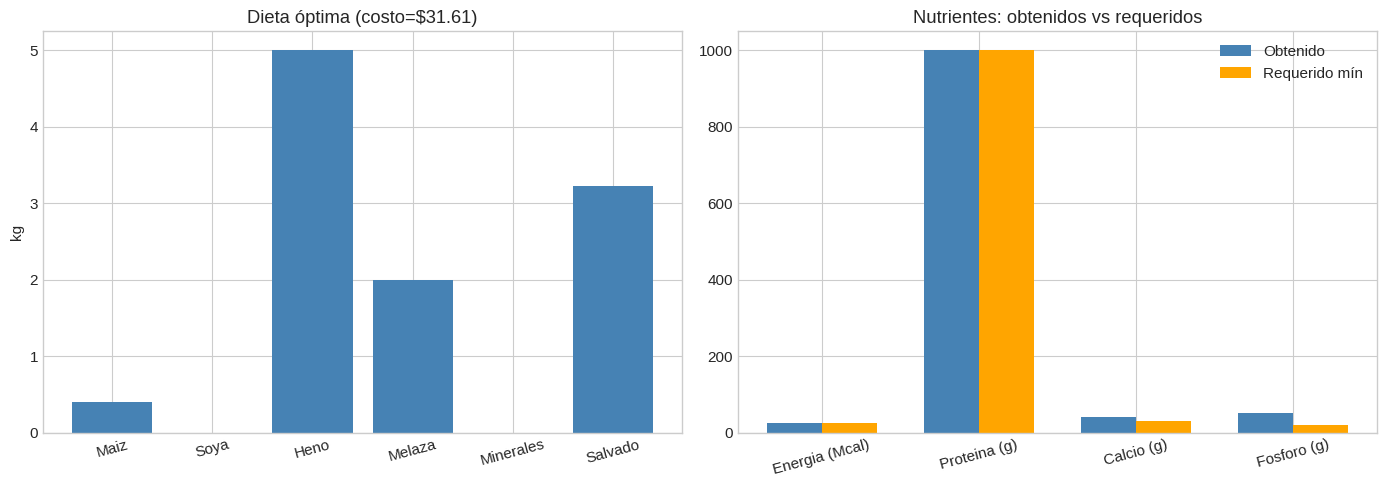

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


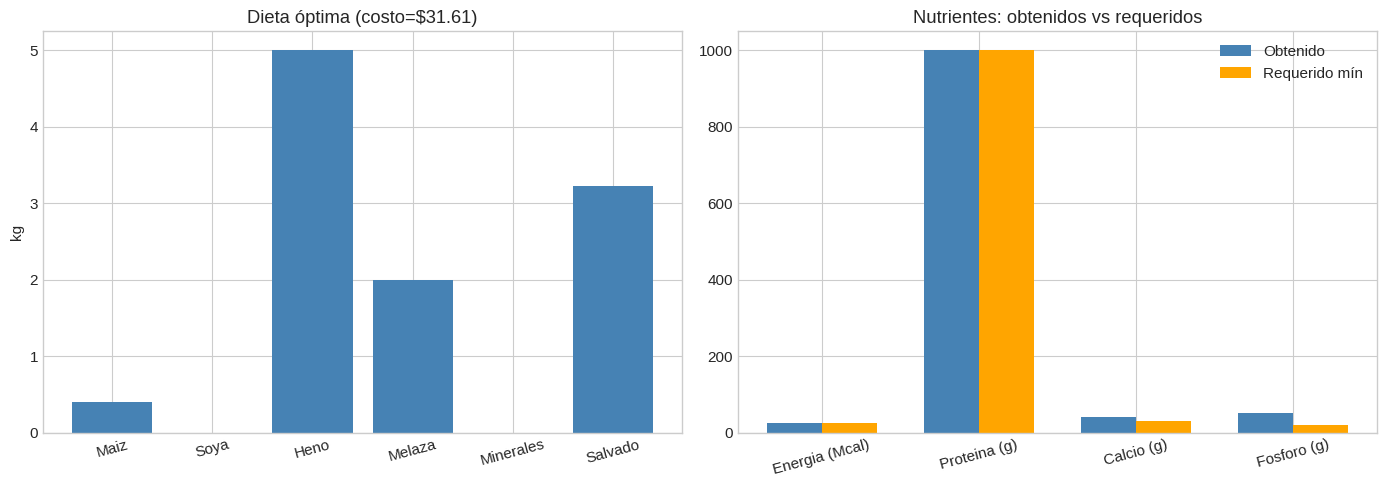

In [7]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: kg por ingrediente
    axes[0].bar(nombres_p1, x_opt, color='steelblue')
    axes[0].set_title(f'Dieta óptima (costo=${costo_opt:.2f})')
    axes[0].set_ylabel('kg')
    axes[0].tick_params(axis='x', rotation=15)

    # Panel 2: nutrientes obtenidos vs requeridos
    info = verificar_p1(x_opt)
    nut = info['nutrientes_totales']
    x_pos = np.arange(len(nombres_nutrientes_p1))
    width = 0.35
    axes[1].bar(x_pos - width/2, nut, width, label='Obtenido', color='steelblue')
    axes[1].bar(x_pos + width/2, req_min_p1, width, label='Requerido mín', color='orange')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(nombres_nutrientes_p1, rotation=15)
    axes[1].set_title('Nutrientes: obtenidos vs requeridos')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

**Variables de decision:**

$$w_i = \text{proporción del capital invertida en activo } i, \quad i \in \{1,...,5\}$$

**Funcion objetivo:**

$$\min \mathbf{w}^T \Sigma \mathbf{w}$$

**Restricciones:**

$$\begin{aligned}
& \sum_{i=1}^{5} \mu_i w_i \geq 0.08 \quad \text{(rendimiento mínimo)}\\
& \sum_{i=1}^{5} w_i = 1 \quad \text{(todo el capital invertido)}\\
& 0 \leq w_i \leq 0.40 \quad \forall i \quad \text{(sin cortos, max 40\%)}
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.minimize` con método SLSQP

**Justificacion:** La función objetivo es cuadrática (varianza del portafolio w^T Σ w)
con restricciones lineales de igualdad y desigualdad. SLSQP (Sequential Least Squares
Programming) está diseñado para optimización cuadrática con restricciones y converge
al óptimo global en este tipo de problema convexo.

In [8]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [9]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    return w @ cov_p2 @ w

def verificar_p2(w):
    rendimiento = w @ rendimientos_p2
    varianza = w @ cov_p2 @ w
    factible = (
        rendimiento >= retorno_minimo_p2 and
        np.isclose(np.sum(w), 1.0, atol=1e-4) and
        np.all(w >= -1e-6) and
        np.all(w <= max_por_activo_p2 + 1e-6)
    )
    return {
        'factible': factible,
        'rendimiento': rendimiento,
        'varianza': varianza,
        'suma_pesos': np.sum(w)
    }

def resolver_p2():
    from scipy.optimize import minimize
    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: w @ rendimientos_p2 - retorno_minimo_p2},
    ]
    bounds = [(0, max_por_activo_p2)] * 5
    w0 = np.ones(5) / 5
    res = minimize(objetivo_p2, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x, res.fun

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


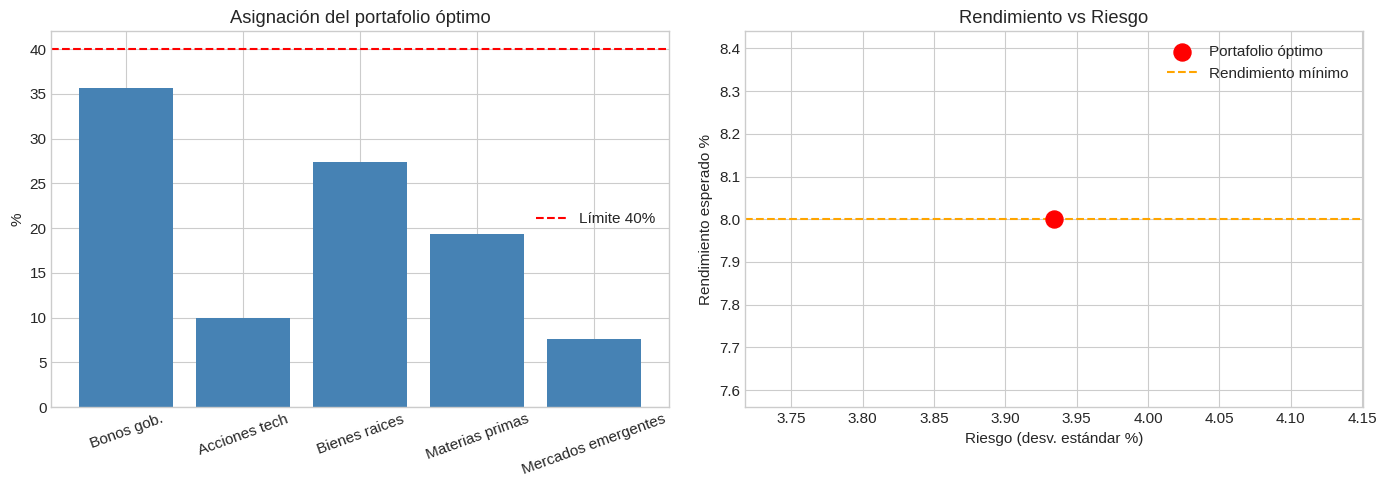

In [11]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: asignación por activo
    axes[0].bar(activos_p2, w_opt * 100, color='steelblue')
    axes[0].axhline(y=max_por_activo_p2*100, color='red', linestyle='--', label='Límite 40%')
    axes[0].set_title('Asignación del portafolio óptimo')
    axes[0].set_ylabel('%')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend()

    # Panel 2: rendimiento vs riesgo
    rend = w_opt @ rendimientos_p2
    std = np.sqrt(varianza_opt)
    axes[1].scatter([std*100], [rend*100], color='red', s=150, zorder=5, label='Portafolio óptimo')
    axes[1].axhline(y=retorno_minimo_p2*100, color='orange', linestyle='--', label='Rendimiento mínimo')
    axes[1].set_xlabel('Riesgo (desv. estándar %)')
    axes[1].set_ylabel('Rendimiento esperado %')
    axes[1].set_title('Rendimiento vs Riesgo')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

**Variables de decision:**

$$y_j \in \{0,1\} = \text{1 si se construye la torre } j, \quad j \in \{1,...,7\}$$

**Funcion objetivo:**

$$\min \sum_{j=1}^{7} c_j y_j = 50y_1+80y_2+60y_3+70y_4+90y_5+40y_6+75y_7$$

**Restricciones:**

$$\begin{aligned}
& \sum_{j=1}^{7} a_{ij} y_j \geq 1 \quad \forall i \in \{1,...,10\} \quad \text{(cada zona cubierta al menos una vez)}\\
& y_j \in \{0,1\} \quad \forall j
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.milp`

**Justificacion:** Las variables de decisión son binarias (construir o no cada torre),
lo que hace de este un problema de programación lineal entera. `milp` de scipy permite
especificar integrality constraints sobre variables individuales y resuelve el óptimo
global garantizado.

In [12]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [13]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    return costos_torres_p3 @ y

def verificar_p3(y):
    cobertura_total = cobertura_p3.T @ y  # (10,)
    cubiertas = [i+1 for i in range(n_zonas_p3) if cobertura_total[i] >= 1]
    sin_cubrir = [i+1 for i in range(n_zonas_p3) if cobertura_total[i] < 1]
    return {
        'factible': len(sin_cubrir) == 0,
        'zonas_cubiertas': cubiertas,
        'zonas_sin_cubrir': sin_cubrir
    }

def resolver_p3():
    from scipy.optimize import milp, LinearConstraint, Bounds
    c = costos_torres_p3.astype(float)
    # Cada zona debe ser cubierta: cobertura_p3.T @ y >= 1
    A = cobertura_p3.T.astype(float)  # (10, 7)
    constraints = LinearConstraint(A, lb=1, ub=np.inf)
    bounds = Bounds(lb=0, ub=1)
    integrality = np.ones(n_torres_p3)
    res = milp(c, constraints=constraints, integrality=integrality, bounds=bounds)
    return res.x, res.fun

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


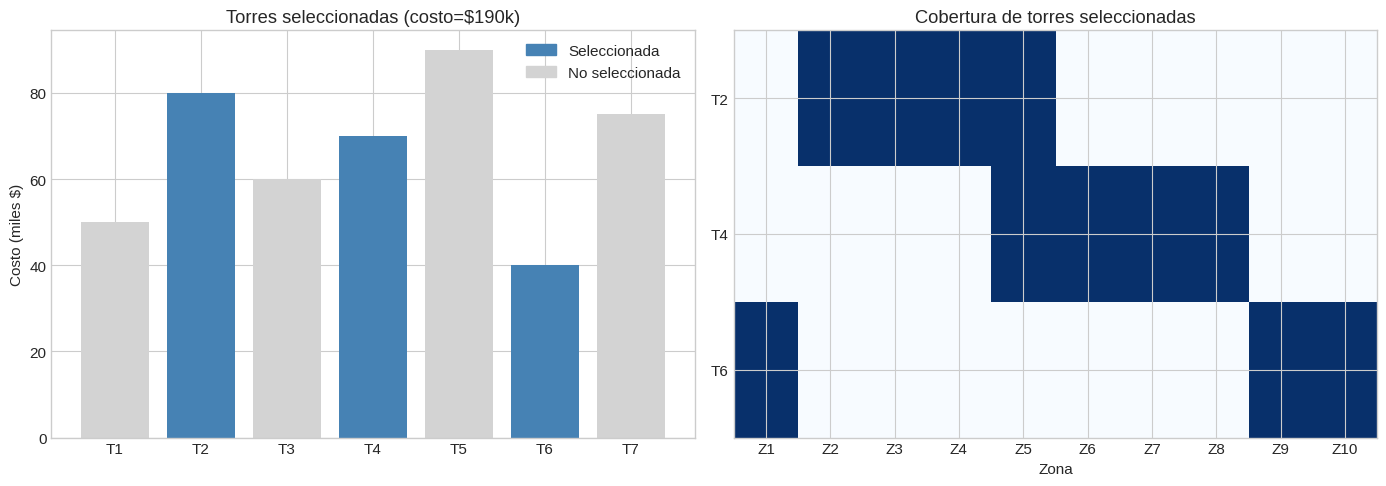

In [14]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    torres_sel = [i for i in range(n_torres_p3) if y_opt[i] > 0.5]
    costos_sel = [costos_torres_p3[i] for i in torres_sel]
    nombres_sel = [nombres_torres_p3[i] for i in torres_sel]

    # Panel 1: torres seleccionadas con costo
    colores = ['steelblue' if y > 0.5 else 'lightgray' for y in y_opt]
    axes[0].bar(nombres_torres_p3, costos_torres_p3, color=colores)
    axes[0].set_title(f'Torres seleccionadas (costo=${costo_opt:.0f}k)')
    axes[0].set_ylabel('Costo (miles $)')
    axes[0].legend(handles=[
        plt.Rectangle((0,0),1,1, color='steelblue', label='Seleccionada'),
        plt.Rectangle((0,0),1,1, color='lightgray', label='No seleccionada')
    ])

    # Panel 2: mapa de cobertura
    cob_sel = cobertura_p3[torres_sel, :]
    axes[1].imshow(cob_sel, cmap='Blues', aspect='auto')
    axes[1].set_xticks(range(n_zonas_p3))
    axes[1].set_xticklabels([f'Z{i+1}' for i in range(n_zonas_p3)])
    axes[1].set_yticks(range(len(torres_sel)))
    axes[1].set_yticklabels(nombres_sel)
    axes[1].set_title('Cobertura de torres seleccionadas')
    axes[1].set_xlabel('Zona')

    plt.tight_layout()
    plt.show()

y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

**Variables de decision:**

$$\theta = (a, b, c, d) \in \mathbb{R}^4$$

**Funcion objetivo:**

$$\min_{a,b,c,d} \sum_{k=1}^{20} \left( a\sin(bt_k+c) + de^{-0.1t_k} - y_k \right)^2$$

**Restricciones:**

$$\begin{aligned}
& a \in [0,5],\; b \in [0,10],\; c \in [0,2\pi],\; d \in [-3,3]
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.differential_evolution`

**Justificacion:** El paisaje de error tiene múltiples mínimos locales debido a los
términos trigonométricos, por lo que métodos basados en gradiente quedarían atrapados
en un mínimo local. `differential_evolution` es un algoritmo de optimización global
estocástico que explora todo el espacio de búsqueda y encuentra el mínimo global
con alta probabilidad sin requerir gradientes.

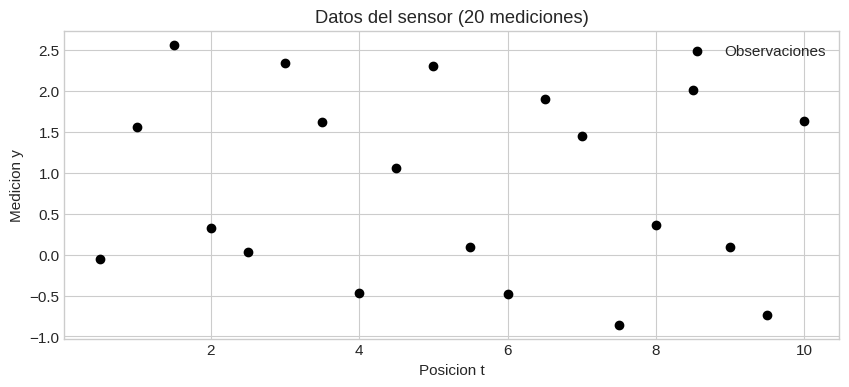

In [15]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [16]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    y_pred = modelo_sensor(t_obs_p4, params)
    return np.sum((y_pred - y_obs_p4) ** 2)

def resolver_p4():
    from scipy.optimize import differential_evolution
    res = differential_evolution(objetivo_p4, bounds_p4, seed=42, maxiter=2000, tol=1e-8)
    return res.x, res.fun

Solucion P4:
  a = 1.5090
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error: 0.088386


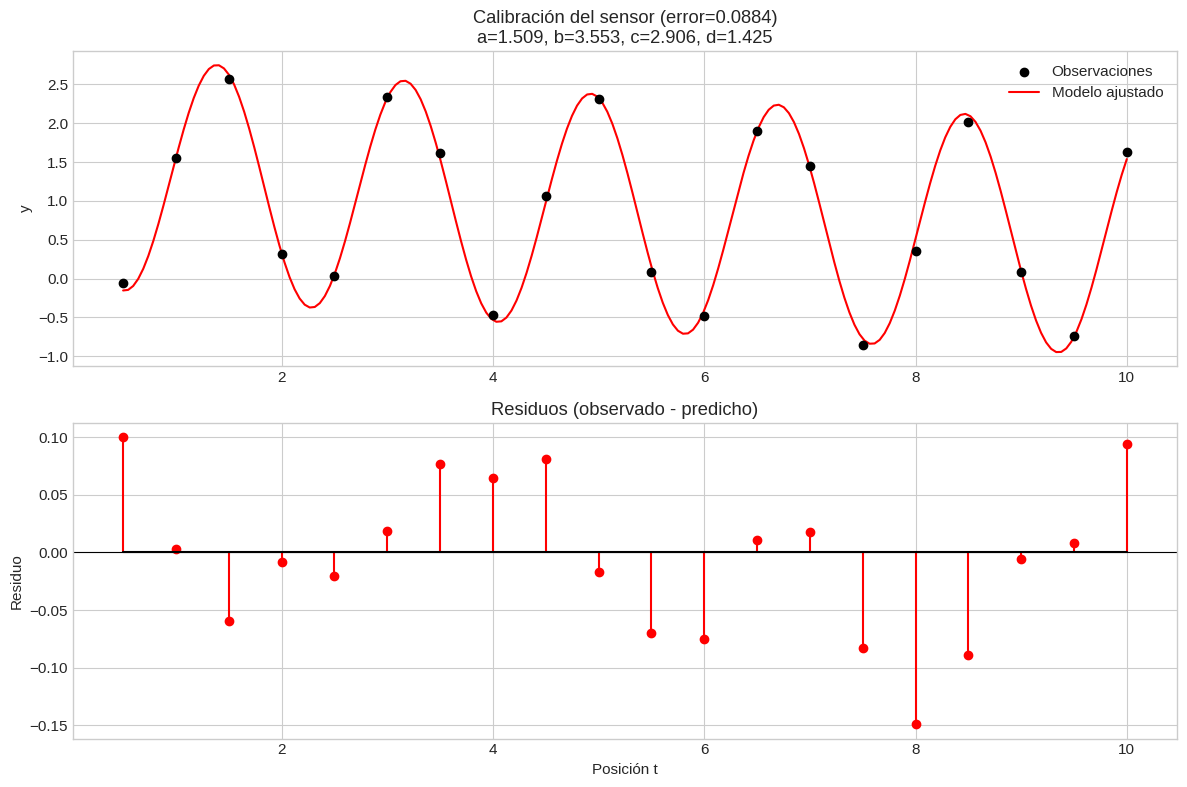

In [17]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    t_fine = np.linspace(t_obs_p4[0], t_obs_p4[-1], 200)
    y_fit = modelo_sensor(t_fine, params_opt)
    y_pred_obs = modelo_sensor(t_obs_p4, params_opt)
    residuos = y_obs_p4 - y_pred_obs

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Panel 1: datos vs modelo ajustado
    axes[0].scatter(t_obs_p4, y_obs_p4, color='black', zorder=5, label='Observaciones')
    axes[0].plot(t_fine, y_fit, color='red', label='Modelo ajustado')
    axes[0].set_title(f'Calibración del sensor (error={error_opt:.4f})\n'
                      f'a={params_opt[0]:.3f}, b={params_opt[1]:.3f}, '
                      f'c={params_opt[2]:.3f}, d={params_opt[3]:.3f}')
    axes[0].set_ylabel('y')
    axes[0].legend()

    # Panel 2: residuos
    axes[1].stem(t_obs_p4, residuos, markerfmt='ro', linefmt='r-', basefmt='k-')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('Residuos (observado - predicho)')
    axes[1].set_xlabel('Posición t')
    axes[1].set_ylabel('Residuo')

    plt.tight_layout()
    plt.show()

params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

**Variables de decision:**

$$y_j \in \{0,1\} = \text{1 si se abre el CD } j, \quad j \in \{1,...,4\}$$
$$x_{ij} \geq 0 = \text{unidades enviadas del CD } j \text{ al cliente } i$$

**Funcion objetivo:**

$$\min \sum_{j=1}^{4} f_j y_j + \sum_{j=1}^{4}\sum_{i=1}^{6} c_{ij} x_{ij}$$

**Restricciones:**

$$\begin{aligned}
& \sum_{j=1}^{4} x_{ij} = d_i \quad \forall i \quad \text{(demanda satisfecha)}\\
& \sum_{i=1}^{6} x_{ij} \leq K_j y_j \quad \forall j \quad \text{(capacidad y apertura)}\\
& y_j \in \{0,1\},\; x_{ij} \geq 0
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.milp`

**Justificacion:** El problema mezcla variables binarias (abrir/no abrir CDs) con
variables continuas (unidades a enviar), lo que lo convierte en un problema de
programación lineal entera mixta (MILP). `milp` de scipy maneja exactamente esta
combinación y resuelve el óptimo global con restricciones lineales.

In [18]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [19]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    return costos_fijos_p5 @ y + np.sum(costos_envio_p5 * X)

def verificar_p5(y, X):
    demanda_cumplida = X.sum(axis=0)  # suma por columna = lo que recibe cada cliente
    capacidad_usada = X.sum(axis=1)  # suma por fila = lo que sale de cada CD
    factible = (
        np.allclose(demanda_cumplida, demandas_p5, atol=1) and
        np.all(capacidad_usada <= capacidades_p5 * y + 1e-3) and
        np.all(X >= -1e-6)
    )
    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    }

def resolver_p5():
    from scipy.optimize import milp, LinearConstraint, Bounds
    # Variables: x[j,i] (n_cds x n_clientes = 24) aplanadas + y[j] (4 binarias)
    # Orden: x00,x01,...,x05, x10,...,x35, y0,y1,y2,y3
    nc, ncd, ncl = n_cds_p5 * n_clientes_p5, n_cds_p5, n_clientes_p5

    c_obj = np.concatenate([costos_envio_p5.flatten(), costos_fijos_p5.astype(float)])

    # Restricción demanda: para cada cliente i, sum_j x[j,i] = d[i]
    A_dem = np.zeros((ncl, nc + ncd))
    for i in range(ncl):
        for j in range(ncd):
            A_dem[i, j*ncl + i] = 1

    # Restricción capacidad: sum_i x[j,i] - K[j]*y[j] <= 0
    A_cap = np.zeros((ncd, nc + ncd))
    for j in range(ncd):
        for i in range(ncl):
            A_cap[j, j*ncl + i] = 1
        A_cap[j, nc + j] = -capacidades_p5[j]

    A = np.vstack([A_dem, A_cap])
    lb = np.concatenate([demandas_p5, -np.inf * np.ones(ncd)])
    ub = np.concatenate([demandas_p5, np.zeros(ncd)])

    constraints = LinearConstraint(A, lb=lb, ub=ub)
    bounds = Bounds(
        lb=np.zeros(nc + ncd),
        ub=np.concatenate([np.full(nc, np.inf), np.ones(ncd)])
    )
    integrality = np.concatenate([np.zeros(nc), np.ones(ncd)])

    res = milp(c_obj, constraints=constraints, integrality=integrality, bounds=bounds)
    y_opt = res.x[nc:]
    X_opt = res.x[:nc].reshape(ncd, ncl)
    return y_opt, X_opt, res.fun

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C4: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 70 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 180 unidades
Costo total: $5130k
Factible: True


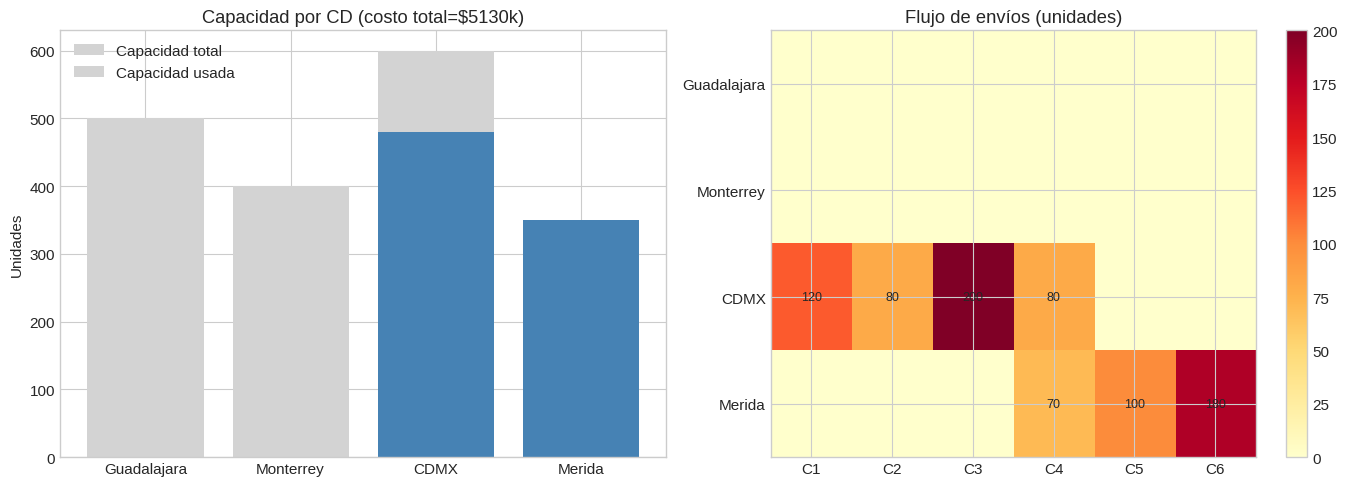

In [20]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: capacidad usada vs disponible por CD
    cap_usada = X_opt.sum(axis=1)
    x_pos = np.arange(ncd := n_cds_p5)
    colores = ['steelblue' if y > 0.5 else 'lightgray' for y in y_opt]
    axes[0].bar(x_pos, capacidades_p5, color='lightgray', label='Capacidad total')
    axes[0].bar(x_pos, cap_usada, color=colores, label='Capacidad usada')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(ciudades_p5)
    axes[0].set_title(f'Capacidad por CD (costo total=${costo_opt:.0f}k)')
    axes[0].set_ylabel('Unidades')
    axes[0].legend()

    # Panel 2: heatmap de flujos
    im = axes[1].imshow(X_opt, cmap='YlOrRd', aspect='auto')
    axes[1].set_xticks(range(n_clientes_p5))
    axes[1].set_xticklabels([f'C{i+1}' for i in range(n_clientes_p5)])
    axes[1].set_yticks(range(n_cds_p5))
    axes[1].set_yticklabels(ciudades_p5)
    axes[1].set_title('Flujo de envíos (unidades)')
    for i in range(n_cds_p5):
        for j in range(n_clientes_p5):
            if X_opt[i,j] > 0.1:
                axes[1].text(j, i, f'{X_opt[i,j]:.0f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=axes[1])

    plt.tight_layout()
    plt.show()

y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)